In [1]:
import xarray as xr
import numpy as np
import functions
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib as mpl
import seaborn as sns
from scipy import stats
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.markers import MarkerStyle
import statsmodels.api as sm
import pymannkendall as mk

In [64]:
def prewhitening(x):

    from scipy.stats import theilslopes
    from statsmodels.tsa.stattools import acf
    import numpy as np

    x = x - np.mean(x)
    slope, intercept, low_slope, high_slope = theilslopes(x, np.arange(len(x)))
    x_detrended = x - slope*np.arange(len(x))
    r1 = acf(x_detrended)[1]
    x_independent = x_detrended
    for i in range(1, (len(x))): x_independent[i] = x_detrended[i] - r1*x_detrended[i-1]
    x_new = x_independent + slope*np.arange(len(x))

    return x_new    

In [2]:
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/'

In [3]:
filepath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/nhsce_v01r01_19661004_20260202.nc'
sce = xr.open_dataset(filepath)

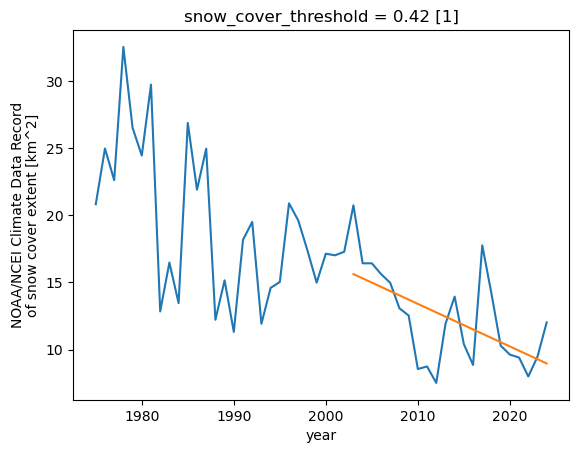

In [70]:
# Select times from 
sce = sce.sel(time=slice('1975-01-01','2025-01-01'))
land_weights = sce.land
latitude_weights = sce.latitude >= 60
longitude_weights = 1-(sce.longitude >= -60)*(sce.longitude <=0)
total_weights = land_weights*longitude_weights*latitude_weights

area_weights = sce.area
total_weights_area = (area_weights*total_weights)
total_area = total_weights_area.sum()

snow_JJA = sce['snow_cover_extent'].sel(time=sce.time.dt.season=='JJA')
snow_JJA = snow_JJA.groupby('time.year').mean('time')
snow_JJA_Arctic_mean = (snow_JJA*total_weights_area/total_area).sum(('y','x'))
#Convert from fraction to percentage
snow_JJA_Arctic_mean = snow_JJA_Arctic_mean*100

# Calculate trend
timeslice_trend=slice(2003,2025)
snow_slope_JJA, snow_intercept_JJA, snow_r_value_JJA, snow_p_value_JJA, snow_std_err_JJA = stats.linregress(snow_JJA_Arctic_mean.sel(year=timeslice_trend).year, snow_JJA_Arctic_mean.sel(year=timeslice_trend).values)

# # Normalize slope value to initial value
snow_slope_JJA_rel = snow_slope_JJA/snow_JJA_Arctic_mean.sel(year=2002)*100
snow_JJA_Arctic_mean.plot()
plt.plot(snow_JJA_Arctic_mean.sel(year=timeslice_trend).year, snow_intercept_JJA+snow_slope_JJA*snow_JJA_Arctic_mean.sel(year=timeslice_trend).year)

In [71]:
snow_MAM = sce['snow_cover_extent'].sel(time=sce.time.dt.season=='MAM')
snow_MAM = snow_MAM.groupby('time.year').mean('time')
snow_MAM_Arctic_mean = (snow_MAM*total_weights_area/total_area).sum(('y','x'))
#Convert from fraction to percentage
snow_MAM_Arctic_mean = snow_MAM_Arctic_mean*100

# Calculate trend
timeslice_trend=slice(2003,2025)
snow_slope_MAM, snow_intercept_MAM, snow_r_value_MAM, snow_p_value_MAM, snow_std_err_MAM = stats.linregress(snow_MAM_Arctic_mean.sel(year=timeslice_trend).year, snow_MAM_Arctic_mean.sel(year=timeslice_trend).values)

# # Normalize slope value to initial value
snow_slope_MAM_rel = snow_slope_MAM/snow_MAM_Arctic_mean.sel(year=2002)*100

In [ ]:
snow_MAM_JJA_mean = 0.5*snow_JJA_Arctic_mean  + 0.5*snow_MAM_Arctic_mean
# Calculate trend
timeslice_trend=slice(2003,2025)
#snow_MAM_JJA_mean_slope, snow_MAM_JJA_mean_intercept, snow_MAM_JJA_mean_r_value, snow_MAM_JJA_mean_p_value, snow_MAM_JJA_mean_std_err = stats.linregress(snow_MAM_JJA_mean.sel(year=timeslice_trend).year, snow_MAM_JJA_mean.sel(year=timeslice_trend).values)

# # Normalize slope value to initial value
#snow_MAM_JJA_mean_slope_rel = snow_MAM_JJA_mean_slope/snow_MAM_JJA_mean.sel(year=2002)*100
#snow_MAM_JJA_mean.plot()
#plt.plot(snow_MAM_JJA_mean.sel(year=timeslice_trend).year, snow_MAM_JJA_mean_intercept+snow_MAM_JJA_mean_slope*snow_MAM_JJA_mean.sel(year=timeslice_trend).year)

snow_slope, snow_intercept, snow_minus, snow_plus = stats.theilslopes(snow_MAM_JJA_mean.sel(year=timeslice_trend), np.arange(len(snow_MAM_JJA_mean.sel(year=timeslice_trend))))
# Normalize slope value to initial value
snow_slope_rel = snow_slope_MAM/snow_MAM_Arctic_mean.sel(year=2003)*100

-0.036935868253784615


In [7]:
filepath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/ERA5_2m_temperature_global.nc'
temp_ERA5 = xr.open_dataset(filepath)
temp_ERA5 = temp_ERA5.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'})
temp_ERA5 = temp_ERA5.reindex(lat=list(reversed(temp_ERA5.lat)))

In [8]:
temp_ERA5_global = functions.computeWeightedMean(temp_ERA5)

In [9]:
temp_ERA5_annual = temp_ERA5_global.groupby('time.year').mean('time')

In [10]:
# Create linear regression
timeslice_trend=slice(2002,2025)
GMST_slope, GMST_intercept, GMST_r_value, GMST_p_value, GMST_std_err = stats.linregress(temp_ERA5_annual.sel(year=timeslice_trend).year, (temp_ERA5_annual['t2m'].sel(year=timeslice_trend)).values)

In [61]:
filepath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/temperature2m_ERA5-Land.nc'
temp_ERA5_Land = xr.open_dataset(filepath)
temp_ERA5_Land = temp_ERA5_Land.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'})
temp_ERA5_Land = temp_ERA5_Land.reindex(lat=list(reversed(temp_ERA5_Land.lat)))
lons = np.array(temp_ERA5_Land.coords['lon'])
lons[np.where(lons<0)] = 360 + lons[np.where(lons<0)]
temp_ERA5_Land.coords['lon'] = lons
temp_ERA5_Land = temp_ERA5_Land.sortby(temp_ERA5_Land.lon)

In [ ]:
season='JJA'
# Select season
temp_ERA5_season = temp_ERA5_Land.sel(time=temp_ERA5_Land.time.dt.season==season)
# Annual season mean
temp_ERA5_season_annual = temp_ERA5_season.groupby(temp_ERA5_season.time.dt.year).mean('time')
# Save file for later use
temp_ERA5_season_annual.to_netcdf(rpath+'t2m_ERA5_JJA_annual.nc')

In [62]:
season='MAM'
# Select season
temp_ERA5_season = temp_ERA5_Land.sel(time=temp_ERA5_Land.time.dt.season==season)
# Annual season mean
temp_ERA5_season_annual = temp_ERA5_season.groupby(temp_ERA5_season.time.dt.year).mean('time')
# Save file for later use
temp_ERA5_season_annual.to_netcdf(rpath+'t2m_ERA5_MAM_annual.nc')

In [103]:
SM_ERA5 = xr.open_dataset(rpath+'SM_ERA5_1970_2025_10cm_20cm.nc')

In [95]:
filepath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/CERES_EBAF-TOA_Ed4.2.1_Subset_200003-202512.nc'
CERES = xr.open_dataset(filepath)
CERES = CERES.sel(time=slice('2003-01-01','2025-12-01'))

In [96]:
# Get land mask for CERES data

# Get land mask for NorESM2
filepath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/other_cloud_vars/LANDFRAC_piClim.nc'
landfrac = xr.open_dataset(filepath)
landmask = landfrac['LANDFRAC'].isel(time=0)

# Interpolate to CERES data
landmask_CERES = landmask.interp_like(CERES.isel(time=0))
# Choose mask points where land fraction is >= 0.9
landmask_CERES = landmask_CERES.where(landmask_CERES>=0.9)
landmask = landmask > 0.90
landmask_CERES = landmask_CERES.fillna(0)

In [ ]:
Arctic_limit=60
lons=slice(0,300)
season='JJA'

# Compute JJA trend over land for CERES
# Regional average, Arctic land excluding Greenland (lons > 300)
CERES_Arctic = functions.computeWeightedMeanMasked(CERES['cldarea_total_daynight_mon'].sel(lat=slice(Arctic_limit, 90),lon=slice(0,300)), landmask_CERES.sel(lat=slice(Arctic_limit, 90),lon=lons))


# Select season
timeslice_trend=slice(2003,2025)
CERES_season = CERES_Arctic.sel(time=CERES_Arctic.time.dt.season==season)
# Annual season mean
CERES_season_annual = CERES_season.groupby(CERES_season.time.dt.year).mean('time')
# Create weighted linear regression
#x = CERES_season_annual.year.values
#x = x
#y = CERES_season_annual.values - CERES_season_annual.values.mean()
#weights = np.ones(len(x))
# Add a smaller weight to first point, as it does not include June
#weights[0] = 2/3



slope, intercept, high_slope, low_slope = stats.theilslopes(y, np.arange(24))

ValueError: Array shapes are incompatible for broadcasting.

In [ ]:
Arctic_limit=60
lons=slice(0,300)
season='JJA'

# Compute JJA trend over land for CERES
# Regional average, Arctic land excluding Greenland (lons > 300)
CERES_Arctic = functions.computeWeightedMeanMasked(CERES['cldarea_total_daynight_mon'].sel(lat=slice(Arctic_limit, 90),lon=slice(0,300)), landmask_CERES.sel(lat=slice(Arctic_limit, 90),lon=lons))
# Select season
CERES_season = CERES_Arctic.sel(time=CERES_Arctic.time.dt.season==season)
# Annual season mean
CERES_season_annual = CERES_season.groupby(CERES_season.time.dt.year).mean('time')

CERES_prewhitened = prewhitening(CERES_season_annual)
mk.original_test(CERES_prewhitened)

In [14]:
Arctic_limit=60
lons=slice(0,300)
season='JJA'

# Compute JJA trend over land for CERES
# Regional average, Arctic land excluding Greenland (lons > 300)
CERES_Arctic = functions.computeWeightedMeanMasked(CERES['cldarea_total_daynight_mon'].sel(lat=slice(Arctic_limit, 90),lon=slice(0,300)), landmask_CERES.sel(lat=slice(Arctic_limit, 90),lon=lons))


# Select season
timeslice_trend=slice(2002,2025)
CERES_season = CERES_Arctic.sel(time=CERES_Arctic.time.dt.season==season)
# Annual season mean
CERES_season_annual = CERES_season.groupby(CERES_season.time.dt.year).mean('time')
# Create weighted linear regression
x = CERES_season_annual.year.values
x = x
y = CERES_season_annual.values
weights = np.ones(len(x))
# Add a smaller weight to first point, as it does not include June
weights[0] = 2/3

# Fit weighted least squares regression model
X = sm.add_constant(x)
model = sm.WLS(y, X, weights=weights)
CERES_fit = model.fit()
CERES_slope = CERES_fit.params[1]
CERES_intercept = CERES_fit.params[0]
CERES_p_value = CERES_fit.pvalues[1]
CERES_std_err = CERES_fit.bse[1]
print(CERES_fit.summary())
CERES_slope_rel = CERES_slope/CERES_season_annual.sel(year=2002)*100



# Compute JJA trend over land for ERA5-Land
timeslice_trend=slice(2002,2025)
ref_timeslice=slice(1970,2000)
# Convert from m3/m3 to kg/m2 (*1000 kg/m3 *0.07 m = 70 kg/m2)
# Convert from m3/m3 to kg/m2 (*1000 kg/m3 *0.20 m = 200 kg/m2)
SM_ERA5_converted = SM_ERA5['swvl_10cm']*100
# Regional average, Arctic excluding Greenland (lons > 300)
SM_ERA5_Arctic = functions.computeWeightedMean(SM_ERA5_converted.sel(lon=lons))
# Select season
SM_ERA5_season = SM_ERA5_Arctic.sel(time=SM_ERA5_Arctic.time.dt.season==season)
# Annual season mean
SM_ERA5_season_annual = SM_ERA5_season.groupby(SM_ERA5_season.time.dt.year).mean('time')
# Reference period mean
SM_ERA5_ref_mean = SM_ERA5_season_annual.sel(year=ref_timeslice).mean('year')
# Create linear regression
SM_ERA5_slope, SM_ERA5_intercept, SM_ERA5_r_value, SM_ERA5_p_value, SM_ERA5_std_err = stats.linregress(SM_ERA5_season_annual.sel(year=timeslice_trend).year, (SM_ERA5_season_annual.sel(year=timeslice_trend)-SM_ERA5_ref_mean).values)
SM_ERA5_slope_rel = SM_ERA5_slope/SM_ERA5_season_annual.sel(year=2002)*100

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.164
Model:                            WLS   Adj. R-squared:                  0.126
Method:                 Least Squares   F-statistic:                     4.324
Date:                Wed, 25 Mar 2026   Prob (F-statistic):             0.0494
Time:                        18:45:53   Log-Likelihood:                -40.621
No. Observations:                  24   AIC:                             85.24
Df Residuals:                      22   BIC:                             87.60
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        241.7296     82.472      2.931      0.0

In [15]:
# Compute JJA temperature trend over land from ERA5-Land
timeslice_trend=slice(2002,2025)
temp_JJA = xr.open_dataset(rpath+'t2m_ERA5_JJA_annual.nc')

lons=slice(0,300)
# Regional average, Arctic excluding Greenland (lons > 300)
temp_JJA = functions.computeWeightedMean(temp_JJA.sel(lon=lons))

# Create linear regression
temp_JJA_slope, temp_JJA_intercept, temp_JJA_r_value, temp_JJA_p_value, temp_JJA_std_err = stats.linregress(temp_JJA.sel(year=timeslice_trend).year, (temp_JJA['t2m'].sel(year=timeslice_trend)).values)

In [16]:
# Compute JJA temperature trend over land from ERA5-Land
timeslice_trend=slice(2002,2025)
temp_MAM = xr.open_dataset(rpath+'t2m_ERA5_MAM_annual.nc')

lons=slice(0,300)
# Regional average, Arctic excluding Greenland (lons > 300)
temp_MAM = functions.computeWeightedMean(temp_MAM.sel(lon=lons))

# Create linear regression
temp_MAM_slope, temp_MAM_intercept, temp_MAM_r_value, temp_MAM_p_value, temp_MAM_std_err = stats.linregress(temp_MAM.sel(year=timeslice_trend).year, (temp_MAM['t2m'].sel(year=timeslice_trend)).values)

In [17]:
# Compute JJA and MAM temperature trend over land from ERA5-Land
timeslice_trend=slice(2002,2025)
temp_MAM = xr.open_dataset(rpath+'t2m_ERA5_MAM_annual.nc')
temp_JJA = xr.open_dataset(rpath+'t2m_ERA5_JJA_annual.nc')

lons=slice(0,300)
# Regional average, Arctic excluding Greenland (lons > 300)
temp_MAM = functions.computeWeightedMean(temp_MAM.sel(lon=lons))
temp_JJA = functions.computeWeightedMean(temp_JJA.sel(lon=lons))

temp_MAM_JJA_mean = temp_MAM*0.5 + temp_JJA*0.5

# Create linear regression
temp_slope_MAM_JJA_mean, temp_intercept_MAM_JJA_mean, temp_r_value_MAM_JJA_mean, temp_p_value_MAM_JJA_mean, temp_std_err_MAM_JJA_mean = stats.linregress(temp_MAM_JJA_mean.sel(year=timeslice_trend).year, (temp_MAM_JJA_mean['t2m'].sel(year=timeslice_trend)).values)

In [18]:
#timeslice=slice('2040-01-01','2069-01-01')
timeslice=slice('1920-01-01','1949-01-01')

rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/'

ds_piClim = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_20250529.soilliq.clm2.concatfiles.nc')
ds_2xCO2 = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_2xCO2_20250529.soilliq.clm2.concatfiles.nc')
ds_4xCO2 = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_4xCO2_20250529.soilliq.clm2.concatfiles.nc')

# Fix time stamp
ds_piClim = functions.fix_clm_time(ds_piClim)
ds_2xCO2 = functions.fix_clm_time(ds_2xCO2)
ds_4xCO2 = functions.fix_clm_time(ds_4xCO2)

# Select timeslice
ds_piClim = ds_piClim.sel(time=timeslice)
ds_2xCO2 = ds_2xCO2.sel(time=timeslice)
ds_4xCO2 = ds_4xCO2.sel(time=timeslice)

# Create new variables
ds_list = [ds_piClim, ds_2xCO2, ds_4xCO2]
for ds in ds_list:
    tmp = ds['SOILICE'] + ds['SOILLIQ']
    tmp = tmp.sel(levsoi=0) + tmp.sel(levsoi=1) + 2/3*tmp.sel(levsoi=2)
    ds['SOILWATER_10CM_corrected'] = tmp

ds_piClim_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_20250529.extra2.clm2.concatfiles.nc')
ds_2xCO2_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_2xCO2_20250529.extra2.clm2.concatfiles.nc')
ds_4xCO2_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_4xCO2_20250529.extra2.clm2.concatfiles.nc')

# Fix time stamp
ds_piClim_xtra = functions.fix_clm_time(ds_piClim_xtra)
ds_2xCO2_xtra = functions.fix_clm_time(ds_2xCO2_xtra)
ds_4xCO2_xtra = functions.fix_clm_time(ds_4xCO2_xtra)

# Select timeslice
ds_piClim_xtra = ds_piClim_xtra.sel(time=timeslice)
ds_2xCO2_xtra = ds_2xCO2_xtra.sel(time=timeslice)
ds_4xCO2_xtra = ds_4xCO2_xtra.sel(time=timeslice)

# Create new variables
ds_list = [ds_piClim, ds_2xCO2, ds_4xCO2]
ds_xtra_list = [ds_piClim_xtra, ds_2xCO2_xtra, ds_4xCO2_xtra]
for ds, ds_xtra in zip(ds_list, ds_xtra_list):
    ds['FSNO'] = ds_xtra['FSNO']

ds_piClim_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_20250529.evaptemp.clm2.concatfiles.nc')
ds_2xCO2_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_2xCO2_20250529.evaptemp.clm2.concatfiles.nc')
ds_4xCO2_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_4xCO2_20250529.evaptemp.clm2.concatfiles.nc')

# Fix time stamp
ds_piClim_xtra = functions.fix_clm_time(ds_piClim_xtra)
ds_2xCO2_xtra = functions.fix_clm_time(ds_2xCO2_xtra)
ds_4xCO2_xtra = functions.fix_clm_time(ds_4xCO2_xtra)

# Select timeslice
ds_piClim_xtra = ds_piClim_xtra.sel(time=timeslice)
ds_2xCO2_xtra = ds_2xCO2_xtra.sel(time=timeslice)
ds_4xCO2_xtra = ds_4xCO2_xtra.sel(time=timeslice)

# Create new variables
ds_list = [ds_piClim, ds_2xCO2, ds_4xCO2]
ds_xtra_list = [ds_piClim_xtra, ds_2xCO2_xtra, ds_4xCO2_xtra]
for ds, ds_xtra in zip(ds_list, ds_xtra_list):
    ds['TSA'] = ds_xtra['TSA']

ds_cloud_piClim = xr.open_dataset(rpath+'other_cloud_vars/CLDTOT_piClim.nc')
ds_cloud_2xCO2 = xr.open_dataset(rpath+'other_cloud_vars/CLDTOT_abrupt-2xCO2.nc')
ds_cloud_4xCO2 = xr.open_dataset(rpath+'other_cloud_vars/CLDTOT_abrupt-4xCO2.nc')

ds_cloud_piClim = ds_cloud_piClim.sel(time=timeslice)
ds_cloud_2xCO2 = ds_cloud_2xCO2.sel(time=timeslice)
ds_cloud_4xCO2 = ds_cloud_4xCO2.sel(time=timeslice)

ds_tas_piClim = xr.open_dataset(rpath+'feedback_input/interval30/tas_piClim_2040-01-01_2069-12-31.nc')
ds_tas_2xCO2 = xr.open_dataset(rpath+'feedback_input/interval30/tas_abrupt-2xCO2_2040-01-01_2069-12-31.nc')
ds_tas_4xCO2 = xr.open_dataset(rpath+'feedback_input/interval30/tas_abrupt-4xCO2_2040-01-01_2069-12-31.nc')

#ds_tas_piClim = xr.open_dataset(rpath+'feedback_input/interval30/tas_piClim_1920-01-01_1949-12-31.nc')
#ds_tas_2xCO2 = xr.open_dataset(rpath+'feedback_input/interval30/tas_abrupt-2xCO2_1920-01-01_1949-12-31.nc')
#ds_tas_4xCO2 = xr.open_dataset(rpath+'feedback_input/interval30/tas_abrupt-4xCO2_1920-01-01_1949-12-31.nc')


In [19]:
# Get area fraction

ds_piClim_area = xr.open_dataset(rpath+'land_vars/all_land_vars_piClim.nc')
ds_piClim_area = ds_piClim_area['area']

In [20]:
ds_piClim = ds_piClim.drop_vars('time_bounds')
ds_2xCO2 = ds_2xCO2.drop_vars('time_bounds')
ds_4xCO2 = ds_4xCO2.drop_vars('time_bounds')

In [21]:
# Create Arctic averages over land excluding greenland
Arctic_lim = 60
lons=slice(0,300)
area_weights = ds_piClim_area.sel(lat=slice(Arctic_lim,90),lon=lons)/(ds_piClim_area.sel(lat=slice(Arctic_lim,90),lon=lons).sum())
ds_piClim_Arctic = (ds_piClim.sel(lat=slice(Arctic_lim,90), lon=lons)*area_weights).sum(dim=['lon','lat'])
ds_2xCO2_Arctic = (ds_2xCO2.sel(lat=slice(Arctic_lim,90), lon=lons)*area_weights).sum(dim=['lon','lat'])
ds_4xCO2_Arctic = (ds_4xCO2.sel(lat=slice(Arctic_lim,90), lon=lons)*area_weights).sum(dim=['lon','lat'])

ds_cloud_piClim_Arctic = functions.computeWeightedMeanMasked(ds_cloud_piClim.sel(lat=slice(Arctic_limit, 90),lon=lons), landmask.sel(lat=slice(Arctic_limit, 90),lon=lons))
ds_cloud_2xCO2_Arctic = functions.computeWeightedMeanMasked(ds_cloud_2xCO2.sel(lat=slice(Arctic_limit, 90),lon=lons), landmask.sel(lat=slice(Arctic_limit, 90),lon=lons))
ds_cloud_4xCO2_Arctic = functions.computeWeightedMeanMasked(ds_cloud_4xCO2.sel(lat=slice(Arctic_limit, 90),lon=lons), landmask.sel(lat=slice(Arctic_limit, 90),lon=lons))


In [22]:
# Create seasonal averages and calculate stds
ds_piClim_Arctic = xr.merge([ds_piClim_Arctic,ds_cloud_piClim_Arctic])
ds_2xCO2_Arctic = xr.merge([ds_2xCO2_Arctic,ds_cloud_2xCO2_Arctic])
ds_4xCO2_Arctic = xr.merge([ds_4xCO2_Arctic,ds_cloud_4xCO2_Arctic])

ds_piClim_Arctic_s = ds_piClim_Arctic.groupby('time.season').mean('time')
ds_2xCO2_Arctic_s = ds_2xCO2_Arctic.groupby('time.season').mean('time')
ds_4xCO2_Arctic_s = ds_4xCO2_Arctic.groupby('time.season').mean('time')

In [23]:
ds_piClim_MAM_JJA = 0.5*ds_piClim_Arctic_s.sel(season='MAM') + 0.5*ds_piClim_Arctic_s.sel(season='JJA')
ds_2xCO2_MAM_JJA = 0.5*ds_2xCO2_Arctic_s.sel(season='MAM') + 0.5*ds_2xCO2_Arctic_s.sel(season='JJA')
ds_4xCO2_MAM_JJA = 0.5*ds_4xCO2_Arctic_s.sel(season='MAM') + 0.5*ds_4xCO2_Arctic_s.sel(season='JJA')

In [24]:
# Compute relative changes
ds_2xCO2_rel = (ds_2xCO2_Arctic_s-ds_piClim_Arctic_s)/ds_piClim_Arctic_s*100
ds_4xCO2_rel = (ds_4xCO2_Arctic_s-ds_piClim_Arctic_s)/ds_piClim_Arctic_s*100

# Compute absolute changes
ds_2xCO2_abs = (ds_2xCO2_Arctic_s-ds_piClim_Arctic_s)
ds_4xCO2_abs = (ds_4xCO2_Arctic_s-ds_piClim_Arctic_s)

In [25]:
# Compute relative changes
ds_2xCO2_rel_MAM_JJA = (ds_2xCO2_MAM_JJA-ds_piClim_MAM_JJA)/ds_piClim_MAM_JJA*100
ds_4xCO2_rel_MAM_JJA = (ds_4xCO2_MAM_JJA-ds_piClim_MAM_JJA)/ds_piClim_MAM_JJA*100

# Compute absolute changes
ds_2xCO2_abs_MAM_JJA = (ds_2xCO2_MAM_JJA-ds_piClim_MAM_JJA)
ds_4xCO2_abs_MAM_JJA = (ds_4xCO2_MAM_JJA-ds_piClim_MAM_JJA)

In [26]:
# Calculate global mean surface temperature change
ds_tas_piClim_global = functions.computeWeightedMean(ds_tas_piClim)
ds_tas_2xCO2_global = functions.computeWeightedMean(ds_tas_2xCO2)
ds_tas_4xCO2_global = functions.computeWeightedMean(ds_tas_4xCO2)

ds_tas_piClim_annual = ds_tas_piClim_global.mean('time')
ds_tas_2xCO2_annual = ds_tas_2xCO2_global.mean('time')
ds_tas_4xCO2_annual = ds_tas_4xCO2_global.mean('time')

dGMST_2xCO2 = ds_tas_2xCO2_annual['tas'] - ds_tas_piClim_annual['tas']
dGMST_4xCO2 = ds_tas_4xCO2_annual['tas'] - ds_tas_piClim_annual['tas']

In [32]:
# Calculate std....
ds_piClim_Arctic_JJA = ds_piClim_Arctic.sel(time=ds_piClim_Arctic.time.dt.season=='JJA').groupby('time.year').mean('time')
ds_2xCO2_Arctic_JJA = ds_2xCO2_Arctic.sel(time=ds_2xCO2_Arctic.time.dt.season=='JJA').groupby('time.year').mean('time')
ds_4xCO2_Arctic_JJA = ds_4xCO2_Arctic.sel(time=ds_4xCO2_Arctic.time.dt.season=='JJA').groupby('time.year').mean('time')

# Normalize by temperature (here: local JJA temp)
#ds_2xCO2_Arctic_JJA = ds_2xCO2_Arctic_JJA/ds_2xCO2_abs['TSA'].sel(season='JJA')
#ds_4xCO2_Arctic_JJA = ds_4xCO2_Arctic_JJA/ds_4xCO2_abs['TSA'].sel(season='JJA')


# Normalize by temperature (here: global annual mean temperature change)
ds_2xCO2_Arctic_JJA = ds_2xCO2_Arctic_JJA/ds_piClim_Arctic_s.sel(season='JJA')*100/dGMST_2xCO2
ds_4xCO2_Arctic_JJA = ds_4xCO2_Arctic_JJA/ds_piClim_Arctic_s.sel(season='JJA')*100/dGMST_4xCO2

# Calculate relative std
ds_piClim_Arctic_JJA_std = ds_piClim_Arctic_JJA.std('year')/ds_piClim_Arctic_s.sel(season='JJA')*100
ds_2xCO2_Arctic_JJA_std = ds_2xCO2_Arctic_JJA.std('year')
ds_4xCO2_Arctic_JJA_std = ds_4xCO2_Arctic_JJA.std('year')

# z-value
#z_value = 1.96 # 95 % confidence level
z_value = 2.048 # 95 % confidence level, n-2=28 (t-value)
ds_piClim_Arctic_JJA_std_err = z_value*ds_piClim_Arctic_JJA_std/np.sqrt(len(ds_piClim_Arctic_JJA.year))
ds_2xCO2_Arctic_JJA_std_err = z_value*ds_2xCO2_Arctic_JJA_std/np.sqrt(len(ds_2xCO2_Arctic_JJA.year))
ds_4xCO2_Arctic_JJA_std_err = z_value*ds_4xCO2_Arctic_JJA_std/np.sqrt(len(ds_4xCO2_Arctic_JJA.year))


ds_2xCO2_Arctic_JJA_std_err = ds_2xCO2_Arctic_JJA_std_err+ds_piClim_Arctic_JJA_std_err
ds_4xCO2_Arctic_JJA_std_err = ds_4xCO2_Arctic_JJA_std_err+ds_piClim_Arctic_JJA_std_err



In [ ]:
# Calculate std....
ds_piClim_Arctic_MAM = ds_piClim_Arctic.sel(time=ds_piClim_Arctic.time.dt.season=='MAM').groupby('time.year').mean('time')
ds_2xCO2_Arctic_MAM = ds_2xCO2_Arctic.sel(time=ds_2xCO2_Arctic.time.dt.season=='MAM').groupby('time.year').mean('time')
ds_4xCO2_Arctic_MAM = ds_4xCO2_Arctic.sel(time=ds_4xCO2_Arctic.time.dt.season=='MAM').groupby('time.year').mean('time')

# Normalize by temperature (here: local MAM temp)
#ds_2xCO2_Arctic_MAM_std_err = ds_2xCO2_Arctic_MAM_std_err/ds_2xCO2_abs['TSA'].sel(season='MAM')
#ds_4xCO2_Arctic_MAM_std_err = ds_4xCO2_Arctic_MAM_std_err/ds_4xCO2_abs['TSA'].sel(season='MAM')

# Normalize by temperature (here: global annual mean temperature change)
ds_2xCO2_Arctic_MAM_std_err = ds_2xCO2_Arctic_MAM_std_err/dGMST_2xCO2
ds_4xCO2_Arctic_MAM_std_err = ds_4xCO2_Arctic_MAM_std_err/dGMST_4xCO2

# Calculate relative std
ds_piClim_Arctic_MAM_std = ds_piClim_Arctic_MAM.std('year')/ds_piClim_Arctic_s.sel(season='MAM')*100
ds_2xCO2_Arctic_MAM_std = ds_2xCO2_Arctic_MAM.std('year')/ds_piClim_Arctic_s.sel(season='MAM')*100
ds_4xCO2_Arctic_MAM_std = ds_4xCO2_Arctic_MAM.std('year')/ds_piClim_Arctic_s.sel(season='MAM')*100

# z-value
#z_value = 1.96 # 95 % confidence level
z_value = 2.048 # 95 % confidence level, n-2=28 (t-value)

ds_piClim_Arctic_MAM_std_err = z_value*ds_piClim_Arctic_MAM_std/np.sqrt(len(ds_piClim_Arctic_MAM.year))
ds_2xCO2_Arctic_MAM_std_err = z_value*ds_2xCO2_Arctic_MAM_std/np.sqrt(len(ds_2xCO2_Arctic_MAM.year))
ds_4xCO2_Arctic_MAM_std_err = z_value*ds_4xCO2_Arctic_MAM_std/np.sqrt(len(ds_4xCO2_Arctic_MAM.year))

ds_2xCO2_Arctic_MAM_std_err = ds_2xCO2_Arctic_MAM_std_err+ds_piClim_Arctic_MAM_std_err
ds_4xCO2_Arctic_MAM_std_err = ds_4xCO2_Arctic_MAM_std_err+ds_piClim_Arctic_MAM_std_err

# Normalize by temperature (here: local MAM temp)
#ds_2xCO2_Arctic_MAM_std_err = ds_2xCO2_Arctic_MAM_std_err/ds_2xCO2_abs['TSA'].sel(season='MAM')
#ds_4xCO2_Arctic_MAM_std_err = ds_4xCO2_Arctic_MAM_std_err/ds_4xCO2_abs['TSA'].sel(season='MAM')

# Normalize by temperature (here: global annual mean temperature change)
ds_2xCO2_Arctic_MAM_std_err = ds_2xCO2_Arctic_MAM_std_err/dGMST_2xCO2
ds_4xCO2_Arctic_MAM_std_err = ds_4xCO2_Arctic_MAM_std_err/dGMST_4xCO2

In [29]:
ds_2xCO2_Arctic_MAM_JJA_std_err = 0.5*ds_2xCO2_Arctic_MAM_std_err+0.5*ds_2xCO2_Arctic_JJA_std_err
ds_4xCO2_Arctic_MAM_JJA_std_err = 0.5*ds_4xCO2_Arctic_MAM_std_err+0.5*ds_4xCO2_Arctic_JJA_std_err

In [30]:
# Calculate standard error for observations
t = 2.074 # based on two-tailed t test for alpa=0.05, n -2 = 22

CERES_std_err_rel = CERES_std_err/CERES_season_annual.sel(year=2002)*100
SM_ERA5_std_err_rel = SM_ERA5_std_err/SM_ERA5_season_annual.sel(year=2002)*100
snow_std_err_rel = snow_MAM_JJA_mean_std_err/snow_MAM_JJA_mean.sel(year=2002)*100
#snow_std_err_rel = snow_std_err_JJA/snow_JJA_Arctic_mean.sel(year=2002)*100
#snow_std_err_rel = snow_std_err_JJA/snow_JJA_Arctic_mean.sel(year=2002)*100


temp_JJA_conf = t*temp_JJA_std_err
temp_MAM_conf = t*temp_MAM_std_err
temp_MAM_JJA_conf = t*temp_std_err_MAM_JJA_mean

#CERES_conf = np.max([t*CERES_std_err_rel/(temp_slope+t*temp_std_err),t*CERES_std_err_rel/(temp_slope-t*temp_std_err)])
#SM_ERA5_conf = np.max([t*SM_ERA5_std_err_rel/(temp_slope+t*temp_std_err),t*SM_ERA5_std_err_rel/(temp_slope-t*temp_std_err)])
#snow_conf = np.max([t*snow_std_err_rel/(temp_slope+t*temp_std_err_MAM_JJA_mean),t*snow_std_err_rel/(temp_slope-t*temp_std_err_MAM_JJA_mean)])


CERES_conf = t*CERES_std_err_rel
SM_ERA5_conf = t*SM_ERA5_std_err_rel
snow_conf = t*snow_std_err_rel

<>:4: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:4: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:4: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:40: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:4: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:4: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:4: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not 

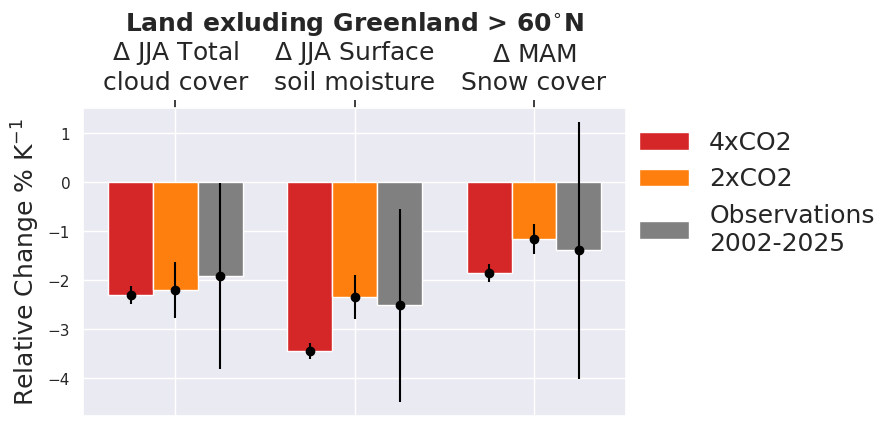

In [37]:
sns.set_theme()
fig, ax = plt.subplots(1, 1, figsize=[7, 4])

vars = ['$\Delta$ JJA Total\ncloud cover', '$\Delta$ JJA Surface\nsoil moisture', '$\Delta$ MAM\nSnow cover']
JJA_change = {
    '4xCO2': [ds_4xCO2_rel['CLDTOT'].sel(season='JJA')/ds_4xCO2_abs['TSA'].sel(season='JJA'),
              ds_4xCO2_rel['SOILWATER_10CM_corrected'].sel(season='JJA')/ds_4xCO2_abs['TSA'].sel(season='JJA'),
              ds_4xCO2_rel['FSNO'].sel(season='MAM')/ds_4xCO2_abs['TSA'].sel(season='MAM')],#ds_4xCO2_rel_MAM_JJA['FSNO']/ds_4xCO2_abs_MAM_JJA['TSA']],

    '2xCO2': [ds_2xCO2_rel['CLDTOT'].sel(season='JJA')/ds_2xCO2_abs['TSA'].sel(season='JJA'),
              ds_2xCO2_rel['SOILWATER_10CM_corrected'].sel(season='JJA')/ds_2xCO2_abs['TSA'].sel(season='JJA'),
              ds_2xCO2_rel['FSNO'].sel(season='MAM')/ds_2xCO2_abs['TSA'].sel(season='MAM')],#ds_2xCO2_rel_MAM_JJA['FSNO']/ds_2xCO2_abs_MAM_JJA['TSA']],
    
    'Observations\n2002-2025': [CERES_slope_rel/temp_JJA_slope,
                                SM_ERA5_slope_rel/temp_JJA_slope,
                                snow_slope_MAM_rel/temp_MAM_slope],
                                }

errors = [[ds_4xCO2_Arctic_JJA_std_err['CLDTOT'], ds_4xCO2_Arctic_JJA_std_err['SOILWATER_10CM_corrected'], ds_4xCO2_Arctic_MAM_std_err['FSNO']],
           [ds_2xCO2_Arctic_JJA_std_err['CLDTOT'], ds_2xCO2_Arctic_JJA_std_err['SOILWATER_10CM_corrected'], ds_2xCO2_Arctic_MAM_std_err['FSNO']],
           [CERES_conf/temp_JJA_slope, SM_ERA5_conf/temp_JJA_slope, snow_conf/temp_MAM_slope]]

x = np.arange(len(vars))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0
colors = ['tab:red', 'tab:orange','grey']
for exp, measurement in JJA_change.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=exp, color=colors[multiplier])
    errorbars = ax.errorbar(x + offset, measurement, yerr=errors[multiplier], fmt="o", color="black")
    multiplier += 1

#ax.set_ylim([-25,0.5])
#ax.set_yscale('symlog')
ax.set_xticks(x + width, vars, fontsize=18)
ax.xaxis.tick_top()
#ax.set_xticks([-10, -8, -6, -4, 0], [-80, -60, -40, -20, 0], fontsize=18)
ax.set_ylabel('Relative Change % K$^{-1}$', fontsize=18)
ax.legend(loc='upper right', fontsize=18,bbox_to_anchor=[1.5,1],frameon=False)
ax.set_title('Land exluding Greenland > 60$^{\circ}$N',fontsize=18, fontweight='bold')

fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/Fig5.png')
fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/Fig5.pdf')

<>:4: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:4: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:4: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:40: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:4: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:4: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:4: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not 

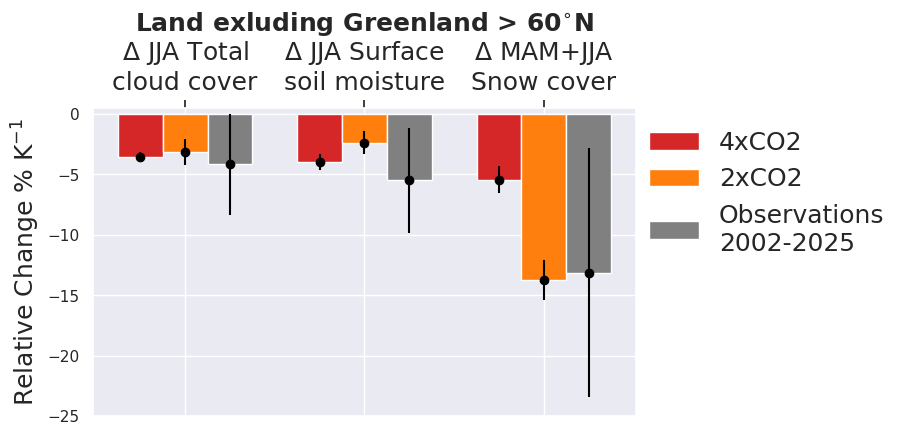

In [31]:
sns.set_theme()
fig, ax = plt.subplots(1, 1, figsize=[7, 4])

vars = ['$\Delta$ JJA Total\ncloud cover', '$\Delta$ JJA Surface\nsoil moisture', '$\Delta$ MAM+JJA\nSnow cover']
JJA_change = {
    '4xCO2': [ds_4xCO2_rel['CLDTOT'].sel(season='JJA')/dGMST_4xCO2,
              ds_4xCO2_rel['SOILWATER_10CM_corrected'].sel(season='JJA')/dGMST_4xCO2,
              ds_4xCO2_rel_MAM_JJA['FSNO']/dGMST_4xCO2],

    '2xCO2': [ds_2xCO2_rel['CLDTOT'].sel(season='JJA')/dGMST_2xCO2,
              ds_2xCO2_rel['SOILWATER_10CM_corrected'].sel(season='JJA')/dGMST_2xCO2,
              ds_4xCO2_rel_MAM_JJA['FSNO']/dGMST_2xCO2],
    
    'Observations\n2002-2025': [CERES_slope_rel/GMST_slope,
                                SM_ERA5_slope_rel/GMST_slope,
                                snow_MAM_JJA_mean_slope_rel/GMST_slope],
                                }

errors = [[ds_4xCO2_Arctic_JJA_std_err['CLDTOT'], ds_4xCO2_Arctic_JJA_std_err['SOILWATER_10CM_corrected'], ds_4xCO2_Arctic_MAM_JJA_std_err['FSNO']],
           [ds_2xCO2_Arctic_JJA_std_err['CLDTOT'], ds_2xCO2_Arctic_JJA_std_err['SOILWATER_10CM_corrected'], ds_2xCO2_Arctic_MAM_JJA_std_err['FSNO']],
           [CERES_conf/GMST_slope, SM_ERA5_conf/GMST_slope, snow_conf/GMST_slope]]

x = np.arange(len(vars))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0
colors = ['tab:red', 'tab:orange','grey']
for exp, measurement in JJA_change.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=exp, color=colors[multiplier])
    errorbars = ax.errorbar(x + offset, measurement, yerr=errors[multiplier], fmt="o", color="black")
    multiplier += 1

ax.set_ylim([-25,0.5])
#ax.set_yscale('symlog')
ax.set_xticks(x + width, vars, fontsize=18)
ax.xaxis.tick_top()
#ax.set_xticks([-10, -8, -6, -4, 0], [-80, -60, -40, -20, 0], fontsize=18)
ax.set_ylabel('Relative Change % K$^{-1}$', fontsize=18)
ax.legend(loc='upper right', fontsize=18,bbox_to_anchor=[1.5,1],frameon=False)
ax.set_title('Land exluding Greenland > 60$^{\circ}$N',fontsize=18, fontweight='bold')

fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/Fig5.png',bbox_inches='tight')
fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/Fig5.pdf',bbox_inches='tight')